# House Price Prediction

## 2.1 Load & Inspect

This section loads the raw Kaggle dataset exactly as downloaded and documents its structure. No cleaning, feature engineering, modeling, or changes to the source CSV are performed here.

### Dataset source and loading approach

The input is the downloaded `house_prices.csv` file in `notebooks/data/`. The path check supports running the notebook from either the project root or the `notebooks/` directory, while always reading the same raw file.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

candidate_paths = [
    Path("notebooks/data/house_prices.csv"),
    Path("data/house_prices.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("Could not find notebooks/data/house_prices.csv.")

df = pd.read_csv(data_path)
print(f"Loaded raw dataset: {data_path.resolve()}")

Loaded raw dataset: D:\House_Price_Project\notebooks\data\house_prices.csv


### Shape and sample rows

The dataset contains **187,531 rows and 21 columns**. The sample below is displayed only to understand the raw listing format and does not alter the data.

In [2]:
print(f"Dataset shape (rows, columns): {df.shape}")
display(df.head())

Dataset shape (rows, columns): (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


### Column types and descriptive statistics

Pandas infers four numeric columns: `Index`, `Price (in rupees)`, `Dimensions`, and `Plot Area`. The remaining 17 columns are text columns at load time. Several fields that represent quantities—such as `Carpet Area`, `Floor`, `Bathroom`, `Balcony`, and `Car Parking`—are currently text, which is expected for this raw dataset and will be addressed only in a later cleaning section.

In [3]:
df.info()

numeric_columns = df.select_dtypes(include="number").columns.tolist()
text_columns = [column for column in df.columns if column not in numeric_columns]

print("\nNumeric columns:")
print(numeric_columns)
print("\nText columns:")
print(text_columns)

display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


### Missing-value review

The columns with the most missing values are `Plot Area` and `Dimensions` (both **100.00%** missing), followed by `Society` (**58.49%**), `Super Area` (**57.42%**), and `Car Parking` (**55.11%**). Other notably incomplete fields include `overlooking` (**43.43%**), `Carpet Area` (**43.02%**), `facing` (**37.45%**), and `Ownership` (**34.94%**). This is an inspection finding only; no imputation, removal, or other cleaning is performed in this section.

In [4]:
missing_percentages = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percentage")
)

display(missing_percentages.to_frame().style.format("{:.2f}%"))

,missing_percentage
Plot Area,100.00%
Dimensions,100.00%
Society,58.49%
Super Area,57.42%
Car Parking,55.11%
overlooking,43.43%
Carpet Area,43.02%
facing,37.45%
Ownership,34.94%
Balcony,26.09%


## 2.2 Exploratory Data Analysis (EDA)

The visualizations below explore the raw dataset. The original `df` is not modified. Small, temporary plotting series are derived only where the raw text values must be displayed numerically; they are not cleaning rules, are not saved, and are not used for modeling.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Temporary, plot-only extraction from raw text. `df` remains unchanged.
amount_parts = (
    df["Amount(in rupees)"]
    .astype("string")
    .str.lower()
    .str.replace(",", "", regex=False)
    .str.extract(r"(?P<value>\d+(?:\.\d+)?)\s*(?P<unit>lac|cr)")
)
eda_price_rupees = pd.to_numeric(amount_parts["value"], errors="coerce") * amount_parts["unit"].map({"lac": 1e5, "cr": 1e7})

# For the scatter plot, retain only carpet-area strings that explicitly state sqft.
# No area-unit normalization or outlier treatment is performed in this EDA section.
carpet_text = df["Carpet Area"].astype("string").str.lower()
carpet_sqft_text = carpet_text.where(carpet_text.str.contains(r"sq\.?\s*ft|sqft", regex=True, na=False))
eda_carpet_sqft_raw = pd.to_numeric(
    carpet_sqft_text.str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)

eda = pd.DataFrame({
    "price_rupees": eda_price_rupees,
    "carpet_sqft_raw": eda_carpet_sqft_raw,
    "location": df["location"],
    "furnishing": df["Furnishing"],
    "bathroom": df["Bathroom"],
})

print(f"Rows with a plottable price: {eda['price_rupees'].notna().sum():,}")

Rows with a plottable price: 177,847


### Target-price distribution

The raw amount strings are converted only into a temporary plotting series so that their distribution can be viewed. A logarithmic x-axis is appropriate because listing prices span several orders of magnitude.

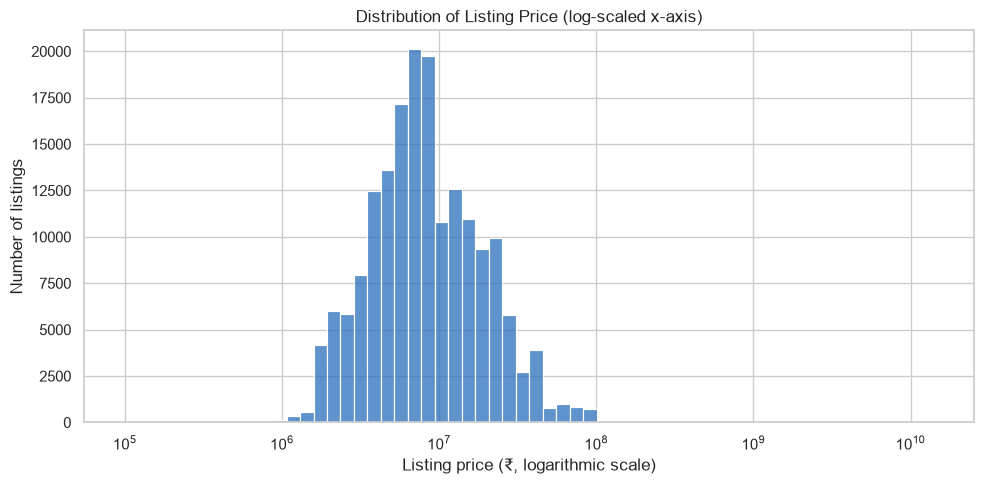

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(eda["price_rupees"].dropna(), bins=60, log_scale=(True, False), color="#2a6fbb")
plt.title("Distribution of Listing Price (log-scaled x-axis)")
plt.xlabel("Listing price (₹, logarithmic scale)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

**Interpretation.** The distribution is strongly right-skewed: the median plottable listing price is about **₹7.8 million**, while a small number of listings extend far higher (up to roughly **₹14.0 billion**). The log scale makes the dense lower and middle ranges visible rather than being dominated by the extreme tail.

### Price versus carpet area

This plot uses only raw carpet-area strings that explicitly contain a square-foot unit. The points are sampled solely for legibility; no records are removed from the original dataset and no unit normalization is performed.

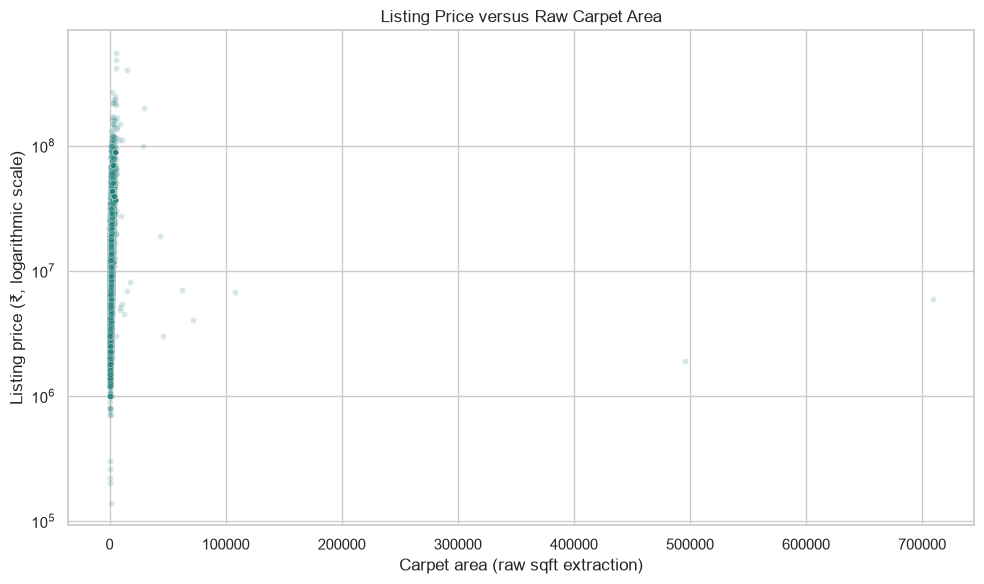

In [7]:
scatter_data = eda.dropna(subset=["price_rupees", "carpet_sqft_raw"])
plot_sample = scatter_data.sample(n=min(25_000, len(scatter_data)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x="carpet_sqft_raw",
    y="price_rupees",
    alpha=0.18,
    s=18,
    color="#207f7b",
)
plt.yscale("log")
plt.title("Listing Price versus Raw Carpet Area")
plt.xlabel("Carpet area (raw sqft extraction)")
plt.ylabel("Listing price (₹, logarithmic scale)")
plt.tight_layout()
plt.show()

**Interpretation.** Prices generally cover a very wide range at any given raw carpet-area value. The raw-series correlation is only about **0.05**, so carpet area alone has little linear explanatory power before location, units, and other data-quality issues are accounted for. The broad spread is a useful reason to inspect and clean the area field later.

### Average price across the 15 most-listed locations

Locations are first ranked by the number of raw listings with a plottable price. The chart then compares their mean listing prices.

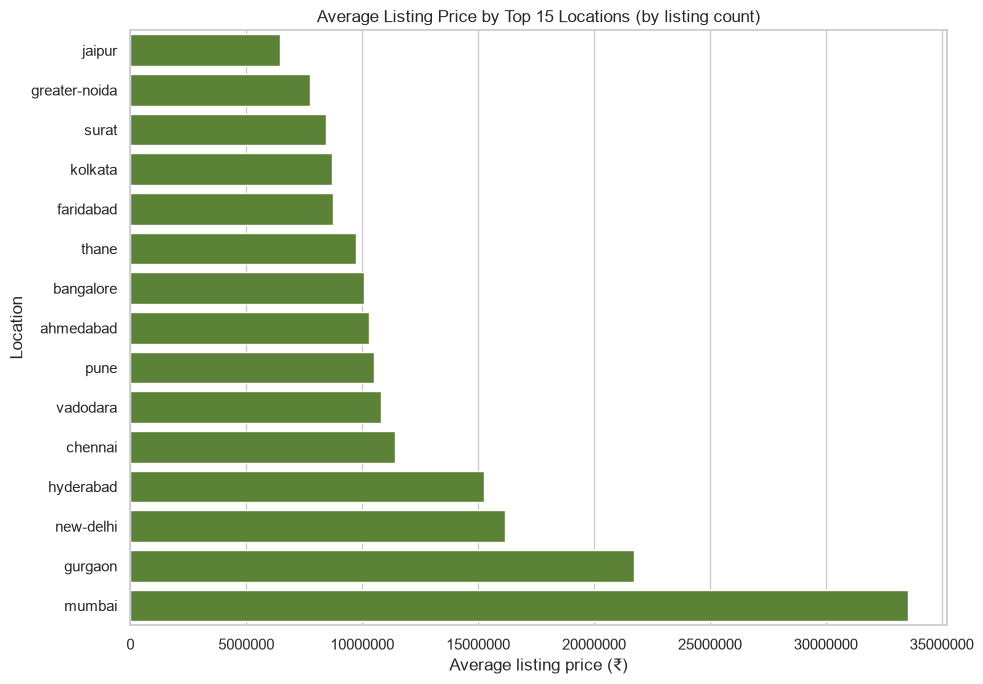

In [8]:
location_data = eda.dropna(subset=["price_rupees", "location"])
top_15_locations = location_data["location"].value_counts().head(15).index
location_means = (
    location_data[location_data["location"].isin(top_15_locations)]
    .groupby("location", as_index=False)["price_rupees"]
    .mean()
    .sort_values("price_rupees")
)

plt.figure(figsize=(10, 7))
sns.barplot(data=location_means, x="price_rupees", y="location", color="#5a8f29")
plt.title("Average Listing Price by Top 15 Locations (by listing count)")
plt.xlabel("Average listing price (₹)")
plt.ylabel("Location")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

**Interpretation.** Location is visibly associated with substantial price differences. Among the 15 locations with the most listings, **Mumbai** has the highest average price (about **₹33.6 million**), followed by **Gurgaon** (about **₹21.7 million**); **Jaipur** is at the lower end (about **₹6.5 million**). This supports retaining location as an important later model input.

### Price by furnishing status

A box plot shows the price distribution within each raw furnishing category. The price axis is logarithmic so the central distributions and high-price tail can be seen together.

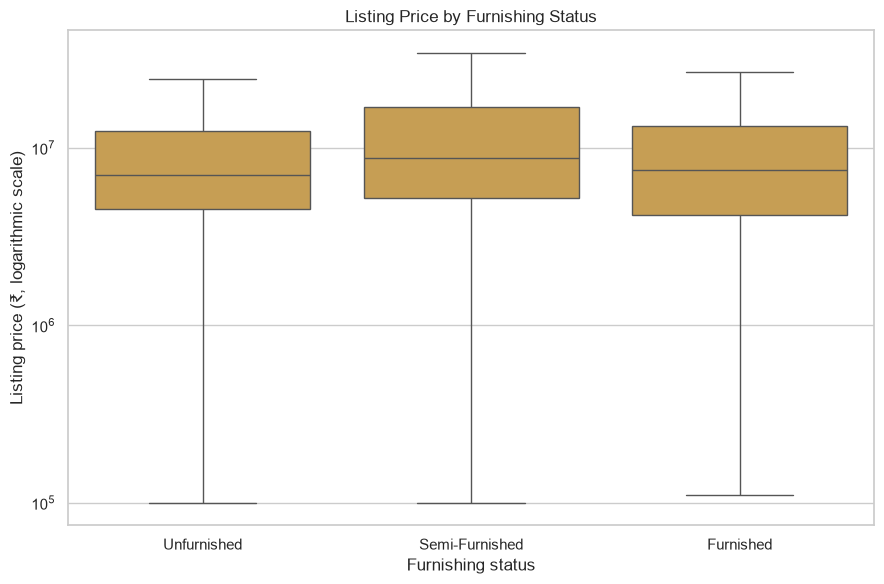

In [9]:
furnishing_data = eda.dropna(subset=["price_rupees", "furnishing"])
furnishing_order = ["Unfurnished", "Semi-Furnished", "Furnished"]

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=furnishing_data,
    x="furnishing",
    y="price_rupees",
    order=[status for status in furnishing_order if status in furnishing_data["furnishing"].unique()],
    color="#d9a441",
    showfliers=False,
)
plt.yscale("log")
plt.title("Listing Price by Furnishing Status")
plt.xlabel("Furnishing status")
plt.ylabel("Listing price (₹, logarithmic scale)")
plt.tight_layout()
plt.show()

**Interpretation.** Semi-furnished listings have the highest median price (about **₹8.75 million**) among the three main categories. Unfurnished listings have the lowest median (about **₹7.0 million**), while the distributions overlap considerably, showing that furnishing is informative but not sufficient on its own to explain price.

### Price by bathroom count

Bathroom values are kept as their original text categories for this visualization; the chart does not coerce, impute, or otherwise clean them.

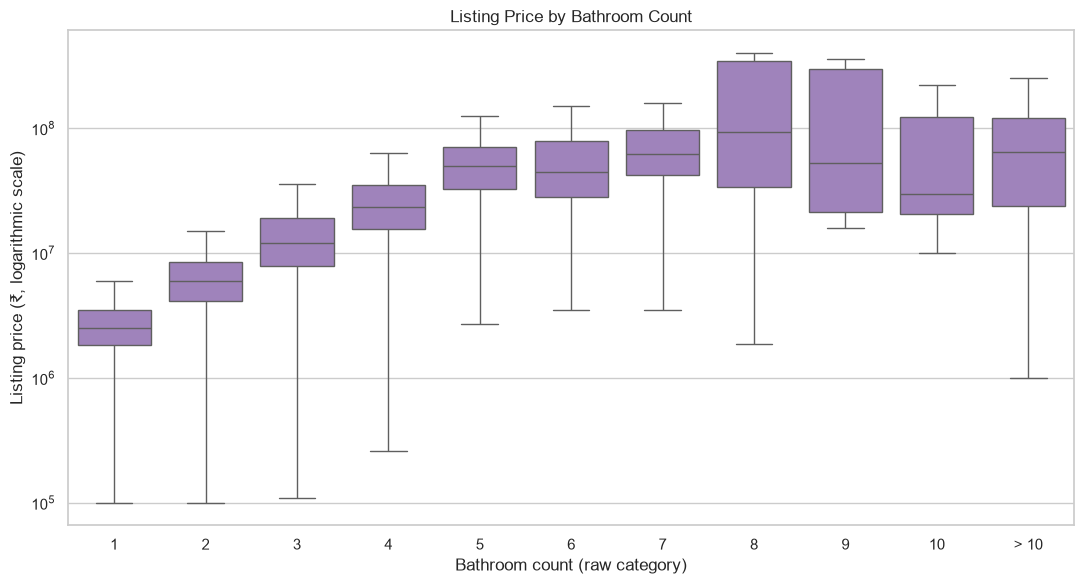

In [10]:
bathroom_data = eda.dropna(subset=["price_rupees", "bathroom"])
bathroom_order = [str(value) for value in range(1, 11)] + ["> 10"]
available_bathroom_order = [value for value in bathroom_order if value in bathroom_data["bathroom"].unique()]

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=bathroom_data,
    x="bathroom",
    y="price_rupees",
    order=available_bathroom_order,
    color="#9f7ac4",
    showfliers=False,
)
plt.yscale("log")
plt.title("Listing Price by Bathroom Count")
plt.xlabel("Bathroom count (raw category)")
plt.ylabel("Listing price (₹, logarithmic scale)")
plt.tight_layout()
plt.show()

**Interpretation.** The median price rises sharply from one bathroom (about **₹2.5 million**) to two (**₹6.0 million**), three (**₹12.1 million**), and four (**₹23.5 million**). The increasing trend and wide within-group spread suggest bathroom count is useful, but interacts with location, area, and other property characteristics.

## 2.3 Cleaning & Feature Engineering

This section begins from a deep copy of the raw dataframe (`clean_df = df.copy(deep=True)`). The raw `df` and the source CSV remain unchanged. The output is a reproducible cleaned dataframe for the next phase; no model, scikit-learn pipeline, train/test split, or evaluation is created here.

### 1. Parse listing price

`Amount(in rupees)` is the listing-price field: it contains values such as `42 Lac`, `1.40 Cr`, and `Call for Price`. The parsing rule converts Lac/Lakh to ₹100,000 and Cr/Crore to ₹10,000,000. Rows without a positive usable listing price are removed because they cannot supply the training target.

In [11]:
import re

clean_df = df.copy(deep=True)
initial_row_count = len(clean_df)

PRICE_MULTIPLIERS = {
    "lac": 100_000,
    "lakh": 100_000,
    "cr": 10_000_000,
    "crore": 10_000_000,
}

def parse_price_to_rupees(value):
    """Convert a raw listing-price string to rupees; return NaN when unusable."""
    if pd.isna(value):
        return float("nan")

    text = str(value).strip().lower().replace(",", "")
    match = re.search(r"(?P<amount>\d+(?:\.\d+)?)\s*(?P<unit>lac|lakh|cr|crore)\b", text)
    if match:
        return float(match.group("amount")) * PRICE_MULTIPLIERS[match.group("unit")]

    # Retain a plain numeric rupee value if a future dataset version contains one.
    if re.fullmatch(r"₹?\s*\d+(?:\.\d+)?", text):
        return float(text.replace("₹", "").strip())

    return float("nan")

clean_df["price_clean"] = clean_df["Amount(in rupees)"].apply(parse_price_to_rupees)
clean_df = clean_df.loc[clean_df["price_clean"].gt(0)].copy()

print(f"Rows before price parsing: {initial_row_count:,}")
print(f"Rows with a usable listing price: {len(clean_df):,}")
print(f"Rows removed for unusable price: {initial_row_count - len(clean_df):,}")

Rows before price parsing: 187,531
Rows with a usable listing price: 177,847
Rows removed for unusable price: 9,684


### 2. Parse and normalize areas

`Carpet Area` and `Super Area` are preserved as raw source fields until two normalized square-foot columns are derived. The parser handles square feet, square metres, square yards, and acres. Missing or unrecognizable values stay missing for later pipeline-based imputation; no rows are removed merely because an area is unavailable.

In [12]:
AREA_TO_SQFT = {
    "sqft": 1.0,
    "sqm": 10.764,
    "sqyd": 9.0,
    "acre": 43_560.0,
}

def parse_area_to_sqft(value):
    """Extract a numeric area and normalize supported units to square feet."""
    if pd.isna(value):
        return float("nan")

    text = str(value).strip().lower().replace(",", "")
    number_match = re.search(r"\d+(?:\.\d+)?", text)
    if not number_match:
        return float("nan")

    amount = float(number_match.group())
    compact = re.sub(r"\s+", "", text)
    if any(token in compact for token in ("sqft", "sq.ft", "squarefeet")):
        return amount * AREA_TO_SQFT["sqft"]
    if any(token in compact for token in ("sqm", "sq.m", "squaremetre", "squaremeter")):
        return amount * AREA_TO_SQFT["sqm"]
    if any(token in compact for token in ("sqyd", "sq.yd", "sqyard", "squareyard")):
        return amount * AREA_TO_SQFT["sqyd"]
    if "acre" in compact:
        return amount * AREA_TO_SQFT["acre"]

    return float("nan")

clean_df["carpet_area_sqft"] = clean_df["Carpet Area"].apply(parse_area_to_sqft)
clean_df["super_area_sqft"] = clean_df["Super Area"].apply(parse_area_to_sqft)

area_coverage = clean_df[["carpet_area_sqft", "super_area_sqft"]].notna().mean().mul(100)
display(area_coverage.rename("non_missing_percentage").to_frame().style.format("{:.2f}%"))

,non_missing_percentage
carpet_area_sqft,54.46%
super_area_sqft,40.91%


### 3. Parse floor number

`Floor` values such as `3 out of 10` are reduced to the listing’s floor number. `Ground` is represented as 0 and basement values as -1. The total-floor portion is not used in this project because the guide requests the floor number itself.

In [13]:
def parse_floor_number(value):
    if pd.isna(value):
        return float("nan")

    text = str(value).strip().lower()
    if "basement" in text:
        return -1.0
    if "ground" in text:
        return 0.0

    match = re.search(r"\d+", text)
    return float(match.group()) if match else float("nan")

clean_df["floor_num"] = clean_df["Floor"].apply(parse_floor_number)
print(f"Non-missing parsed floors: {clean_df['floor_num'].notna().mean():.2%}")

Non-missing parsed floors: 96.09%


### 4. Convert Bathroom, Balcony, and Car Parking to numeric values

The first numeric value is extracted from each raw field (for example, `1 Covered` becomes 1). A `> 10` value becomes 11. Missing values are imputed with the median of the parsed column, as required. The raw parking field contains implausibly large entries such as `402 Covered`; this quality issue is retained in the cleaning summary and is one reason parking is not part of the initial baseline feature set.

In [14]:
def parse_count(value):
    if pd.isna(value):
        return float("nan")

    text = str(value).strip()
    match = re.search(r"\d+(?:\.\d+)?", text)
    if not match:
        return float("nan")

    parsed = float(match.group())
    return parsed + 1 if text.startswith(">") else parsed

numeric_source_columns = {
    "bathroom": "Bathroom",
    "balcony": "Balcony",
    "car_parking": "Car Parking",
}

imputation_values = {}
for clean_name, raw_name in numeric_source_columns.items():
    clean_df[clean_name] = clean_df[raw_name].apply(parse_count)
    imputation_values[clean_name] = clean_df[clean_name].median()
    clean_df[clean_name] = clean_df[clean_name].fillna(imputation_values[clean_name])

print("Median values used for numeric imputation:")
print(pd.Series(imputation_values).to_string())

Median values used for numeric imputation:
bathroom       2.0
balcony        2.0
car_parking    1.0


### 5. Handle high-cardinality location and society values

The actual dataset has 81 locations and 10,376 societies. To keep the later one-hot encoding tractable and follow the guide, the 50 most frequent non-missing values in each field are retained; less frequent values are labeled `other`. Missing society values are explicitly labeled `missing` rather than being conflated with a real low-frequency society.

In [15]:
TOP_N_CATEGORIES = 50

def group_top_categories(series, top_n=TOP_N_CATEGORIES):
    values = series.astype("string").str.strip()
    top_values = values.dropna().value_counts().head(top_n).index
    values_with_missing = values.fillna("missing")
    return values_with_missing.where(
        values_with_missing.isin(top_values) | values_with_missing.eq("missing"),
        "other",
    )

clean_df["location_grouped"] = group_top_categories(clean_df["location"])
clean_df["society_grouped"] = group_top_categories(clean_df["Society"])

grouped_cardinality = clean_df[["location_grouped", "society_grouped"]].nunique().rename("grouped_unique_values")
display(grouped_cardinality.to_frame())

,grouped_unique_values
location_grouped,51
society_grouped,52


### 6. Drop useless, empty, duplicated, and raw-source columns

`Index`, `Title`, and `Description` are identifiers/free text rather than selected model inputs. `Dimensions` and `Plot Area` are dropped because the inspection found them 100% missing. `Price (in rupees)` is also removed: the listing-price target comes from `Amount(in rupees)`, while this second price-like field has an undocumented meaning and would risk leakage or misinterpretation. Once cleaned replacements exist, the corresponding raw text fields are removed to prevent duplicate representations.

In [16]:
columns_to_drop = [
    "Index",
    "Title",
    "Description",
    "Amount(in rupees)",
    "Price (in rupees)",
    "location",
    "Carpet Area",
    "Super Area",
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "Society",
    "Dimensions",
    "Plot Area",
]
clean_df = clean_df.drop(columns=columns_to_drop)

print("Columns retained after source-column removal:")
print(clean_df.columns.tolist())

Columns retained after source-column removal:
['Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'price_clean', 'carpet_area_sqft', 'super_area_sqft', 'floor_num', 'bathroom', 'balcony', 'car_parking', 'location_grouped', 'society_grouped']


### 7. Remove extreme price-per-square-foot outliers

For rows with both a positive cleaned price and positive normalized carpet area, price per square foot is calculated. Only observations below the 1st percentile or above the 99th percentile of that valid ratio are removed. Rows without a usable carpet area are retained for the later pipeline to impute; they cannot be judged by this specific outlier rule. The temporary ratio is dropped immediately afterwards so it cannot leak target information into a future model.

In [17]:
valid_area_mask = clean_df["carpet_area_sqft"].gt(0)
clean_df["price_per_sqft"] = clean_df["price_clean"].div(clean_df["carpet_area_sqft"])
valid_ppsf_mask = valid_area_mask & clean_df["price_per_sqft"].notna()
ppsf_lower_bound, ppsf_upper_bound = clean_df.loc[valid_ppsf_mask, "price_per_sqft"].quantile([0.01, 0.99])

outlier_mask = valid_ppsf_mask & (
    clean_df["price_per_sqft"].lt(ppsf_lower_bound)
    | clean_df["price_per_sqft"].gt(ppsf_upper_bound)
)
rows_before_outlier_removal = len(clean_df)
clean_df = clean_df.loc[~outlier_mask].drop(columns="price_per_sqft").copy()

print(f"Valid price-per-sqft rows used to set bounds: {valid_ppsf_mask.sum():,}")
print(f"1st percentile price-per-sqft bound: ₹{ppsf_lower_bound:,.2f}")
print(f"99th percentile price-per-sqft bound: ₹{ppsf_upper_bound:,.2f}")
print(f"Rows removed as price-per-sqft outliers: {outlier_mask.sum():,}")
print(f"Rows remaining after all Phase 2.3 steps: {len(clean_df):,}")

Valid price-per-sqft rows used to set bounds: 96,858
1st percentile price-per-sqft bound: ₹2,692.31
99th percentile price-per-sqft bound: ₹36,000.00
Rows removed as price-per-sqft outliers: 1,595
Rows remaining after all Phase 2.3 steps: 176,252


### Feature-scope decision for the next phase

The guide requires cleaning `Super Area`, `Car Parking`, and `Society` but excludes them from its example model schema. The actual data supports a conservative baseline: `Super Area` is 57.42% missing, `Car Parking` is 55.11% missing and has implausible values, and `Society` is 58.49% missing with 10,376 raw categories. Therefore, the initial model in Phase 2.4 will use the guide’s core baseline features. The three required cleaned fields are retained as clearly labeled secondary candidates for a later comparison, rather than silently discarded. `Status` and `overlooking` are also retained as optional categorical candidates, but are not part of the initial baseline.

In [18]:
baseline_numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "balcony",
]
baseline_categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing",
]
secondary_candidate_features = [
    "super_area_sqft",
    "car_parking",
    "society_grouped",
    "Status",
    "overlooking",
]

print("Target:", "price_clean")
print("Baseline numeric features:", baseline_numeric_features)
print("Baseline categorical features:", baseline_categorical_features)
print("Secondary cleaned candidates (not in the initial baseline):", secondary_candidate_features)
print(f"Final cleaned dataframe shape: {clean_df.shape}")

Target: price_clean
Baseline numeric features: ['carpet_area_sqft', 'floor_num', 'bathroom', 'balcony']
Baseline categorical features: ['location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']
Secondary cleaned candidates (not in the initial baseline): ['super_area_sqft', 'car_parking', 'society_grouped', 'Status', 'overlooking']
Final cleaned dataframe shape: (176252, 15)


## 2.4 Build a Pipeline & Train

The baseline feature scope selected in Phase 2.3 is used here. A single scikit-learn `Pipeline` bundles imputation, scaling, and one-hot encoding with each regressor so the exported artifact can receive raw feature columns directly. The split is fixed with `random_state=42`; all metrics below are calculated only on the held-out test set.

### Reproducible split and preprocessing

The model target is `price_clean`. Numeric features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding with `handle_unknown="ignore"`, which keeps inference robust to a category not seen during training.

In [19]:
import joblib
import numpy as np
import sklearn

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_numeric_features = baseline_numeric_features
model_categorical_features = baseline_categorical_features
model_feature_columns = model_numeric_features + model_categorical_features

X = clean_df[model_feature_columns].copy()
y = clean_df["price_clean"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

def build_preprocessor():
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, model_numeric_features),
            ("categorical", categorical_transformer, model_categorical_features),
        ]
    )

def build_pipeline(regressor):
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("regressor", regressor),
        ]
    )

print(f"scikit-learn version: {sklearn.__version__}")
print(f"Feature columns: {model_feature_columns}")
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")

scikit-learn version: 1.9.0
Feature columns: ['carpet_area_sqft', 'floor_num', 'bathroom', 'balcony', 'location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']
Training rows: 141,001; test rows: 35,251


### Train baseline and log-target models

The required baseline is `LinearRegression`. It is compared with a nonlinear `RandomForestRegressor`. Because the target is strongly skewed, a third model wraps the same RandomForest pipeline in `TransformedTargetRegressor`, training on `log1p(price_clean)` and inverting predictions with `expm1`.

In [20]:
random_forest_parameters = {
    "n_estimators": 100,
    "max_depth": 24,
    "min_samples_leaf": 2,
    "random_state": 42,
    "n_jobs": -1,
}

models = {
    "LinearRegression (raw target)": build_pipeline(LinearRegression()),
    "RandomForestRegressor (raw target)": build_pipeline(
        RandomForestRegressor(**random_forest_parameters)
    ),
    "RandomForestRegressor (log target)": TransformedTargetRegressor(
        regressor=build_pipeline(RandomForestRegressor(**random_forest_parameters)),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
}

test_predictions = {}
evaluation_rows = []

for model_name, estimator in models.items():
    estimator.fit(X_train, y_train)
    predictions = estimator.predict(X_test)
    test_predictions[model_name] = predictions
    evaluation_rows.append(
        {
            "model": model_name,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": root_mean_squared_error(y_test, predictions),
            "R2": r2_score(y_test, predictions),
        }
    )

metrics_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values(["MAE", "RMSE"], ascending=[True, True])
    .reset_index(drop=True)
)

display(metrics_df.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))

,model,MAE,RMSE,R2
0,RandomForestRegressor (log target),"1,319,924.96","4,385,508.17",0.8740
1,RandomForestRegressor (raw target),"1,387,435.62","4,483,296.73",0.8683
2,LinearRegression (raw target),"4,490,859.08","7,660,166.01",0.6155


### Test-set comparison and selected model

The comparison table above is based exclusively on the held-out test rows. The selection rule prioritizes the lowest test MAE (typical absolute prediction error), then the lowest test RMSE as a tie-breaker. R² is reported as an additional goodness-of-fit measure.

**Winner justification.** LinearRegression is a useful baseline, but it cannot capture the nonlinear relationships that the EDA already suggested: price is heavily right-skewed, location effects are large, and area has a weak linear association with price. The raw-target RandomForest already cuts test MAE from about ₹4.49 million to about ₹1.39 million and raises R² from 0.62 to 0.87. Training the same forest on `log1p(price)` and inverting with `expm1` improves the typical error further (test MAE ₹1.32 million vs ₹1.39 million, with a slightly better RMSE and R² as well). That is the expected benefit of a log target on skewed listing prices: large listings no longer dominate the loss as strongly, so typical rupee error on ordinary homes falls. The exported model is therefore **RandomForestRegressor (log target)**.

In [21]:
best_model_name = metrics_df.iloc[0]["model"]
selected_model = models[best_model_name]
selected_metrics = metrics_df.iloc[0].to_dict()

print(f"Selected model: {best_model_name}")
print(f"Selection metrics — MAE: ₹{selected_metrics['MAE']:,.2f}; RMSE: ₹{selected_metrics['RMSE']:,.2f}; R²: {selected_metrics['R2']:.4f}")
print("The selected model has the lowest held-out test MAE under the documented selection rule.")

Selected model: RandomForestRegressor (log target)
Selection metrics — MAE: ₹1,319,924.96; RMSE: ₹4,385,508.17; R²: 0.8740
The selected model has the lowest held-out test MAE under the documented selection rule.


### Predicted versus actual prices

The scatter below uses only the held-out test rows and the already-fitted selected model. Predictions are reused from `test_predictions`; the model is not retrained. A log–log scale is used because listing prices span several orders of magnitude. Points near the diagonal are accurate; systematic departure from the diagonal would indicate bias.

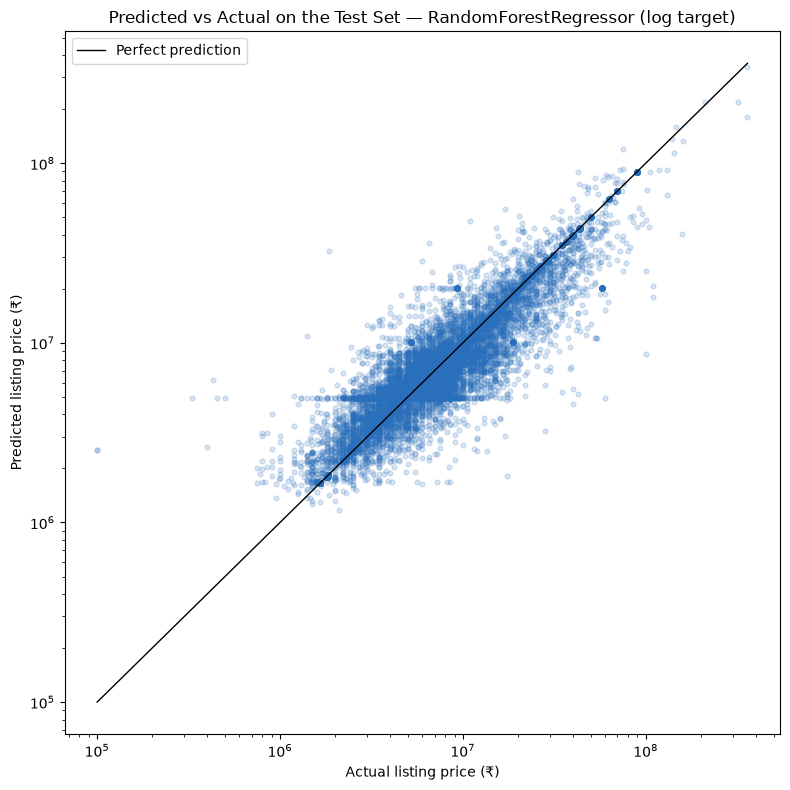

In [22]:
selected_predictions = test_predictions[best_model_name]
plot_sample_size = min(25_000, len(y_test))
predicted_vs_actual = (
    pd.DataFrame({"actual": y_test.to_numpy(), "predicted": selected_predictions})
    .sample(n=plot_sample_size, random_state=42)
)

plt.figure(figsize=(8, 8))
plt.scatter(
    predicted_vs_actual["actual"],
    predicted_vs_actual["predicted"],
    alpha=0.18,
    s=12,
    color="#2a6fbb",
)
axis_min = min(predicted_vs_actual["actual"].min(), predicted_vs_actual["predicted"].min())
axis_max = max(predicted_vs_actual["actual"].max(), predicted_vs_actual["predicted"].max())
plt.plot([axis_min, axis_max], [axis_min, axis_max], color="black", linewidth=1, label="Perfect prediction")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual listing price (₹)")
plt.ylabel("Predicted listing price (₹)")
plt.title(f"Predicted vs Actual on the Test Set — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


### Export the selected trained pipeline

The selected estimator includes its complete preprocessing and regression steps. It is exported as `models/house_price.pkl` for the later backend phase. The exact scikit-learn version is printed and must be pinned when the backend is built. Grouped location labels are exported separately as `models/locations.json` for the backend location dropdown; the pickle itself is not rewritten in the locations-export cell.

In [ ]:
project_root = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
model_output_path = project_root / "models" / "house_price.pkl"
model_output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(selected_model, model_output_path)

reloaded_model = joblib.load(model_output_path)
sanity_prediction = float(reloaded_model.predict(X_test.iloc[[0]])[0])

print(f"Saved selected model to: {model_output_path.resolve()}")
print(f"Reloaded-model sanity prediction for one held-out row: ₹{sanity_prediction:,.2f}")
print(f"Recorded scikit-learn version: {sklearn.__version__}")

Saved selected model to: D:\House_Price_Project\models\house_price.pkl
Reloaded-model sanity prediction for one held-out row: ₹16,494,447.34
Recorded scikit-learn version: 1.9.0


Grouped location labels used by the model (`location_grouped`, including `"other"`) are written to `models/locations.json` for the backend dropdown. This cell does not retrain the model or rewrite `house_price.pkl`.

In [ ]:
import json

project_root = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
locations_output_path = project_root / "models" / "locations.json"
locations_output_path.parent.mkdir(parents=True, exist_ok=True)

locations = sorted(clean_df["location_grouped"].dropna().astype(str).unique().tolist())
locations_output_path.write_text(json.dumps(locations, indent=2), encoding="utf-8")

print(f"Saved {len(locations)} grouped locations to: {locations_output_path.resolve()}")
print("First few locations:", locations[:8])


Saved 51 grouped locations to: D:\House_Price_Project\models\locations.json
First few locations: ['agra', 'ahmedabad', 'aurangabad', 'badlapur', 'bangalore', 'bhiwadi', 'bhubaneswar', 'chandigarh']
